# 🚁 NOTEBOOK 07: FEATURE ANALYSIS & OPTIMIZATION
**Project:** Intelligent Drone Flight Maneuver Recognition  
**Phase:** Optimization (Chuẩn bị cho Mobile Deployment)  

## 🎯 Mục tiêu
1. **Feature Importance:** Hỏi Random Forest xem đặc trưng nào quan trọng nhất?
   - *Kỳ vọng:* `acc_z_kurtosis` (Landing), `acc_z_zcr` (Turbulence), `acc_x_mean` (Maneuver) sẽ đứng đầu.
2. **Feature Selection:** Cắt giảm từ ~54 features xuống còn Top 15-20 features tốt nhất.
3. **Retrain Lite Model:** Huấn luyện lại model nhẹ hơn và so sánh Accuracy.
4. **Export:** Lưu danh sách feature rút gọn để code Android sau này chỉ tính toán những cái cần thiết.

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

drive.mount('/content/drive')
sns.set_theme(style="whitegrid")

# --- CONFIG ---
BASE_DIR = Path('/content/drive/MyDrive/Drone_Project_2025')
FEATURES_DIR = BASE_DIR / 'data/features'
MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Load Full Data
def load_data(name):
    X = pd.read_csv(FEATURES_DIR / f'X_{name}.csv')
    y = pd.read_csv(FEATURES_DIR / f'y_{name}.csv').values.ravel()
    return X, y

X_train, y_train = load_data('train')
X_val, y_val = load_data('val')

# Load Full Model
rf_full = joblib.load(MODELS_DIR / 'rf_model.joblib')
print(f"✅ Data Loaded: Train {X_train.shape}, Val {X_val.shape}")

Mounted at /content/drive
✅ Data Loaded: Train (1750, 84), Val (130, 84)


## 🥇 1. TÌM KIẾM "NGÔI SAO" (FEATURE IMPORTANCE)
Random Forest có thuộc tính `feature_importances_` cho biết mỗi feature đóng góp bao nhiêu % vào quyết định đúng.

/tmp/ipython-input-4278898648.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(20), palette='viridis')


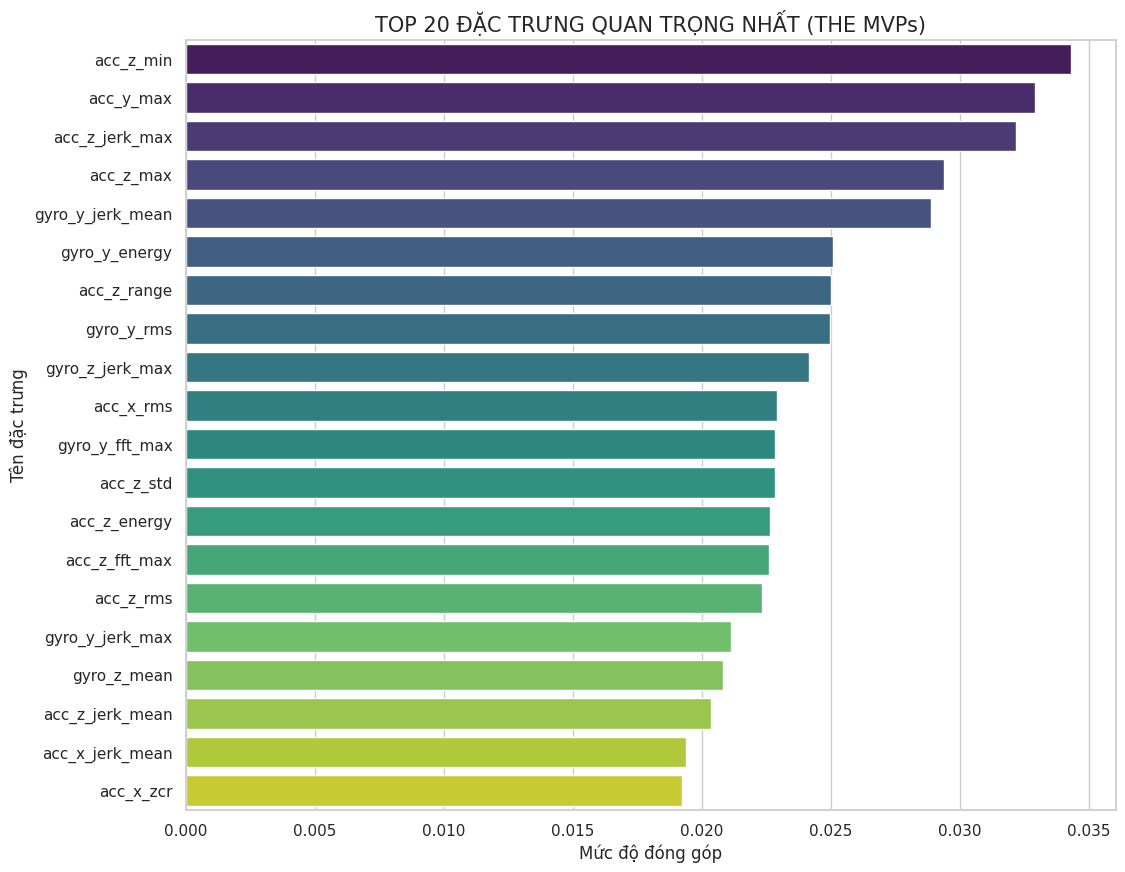

Top 5 Features bá đạo nhất:
             Feature  Importance
31         acc_z_min    0.034322
16         acc_y_max    0.032927
38    acc_z_jerk_max    0.032188
30         acc_z_max    0.029403
65  gyro_y_jerk_mean    0.028882


In [ ]:
# Lấy tầm quan trọng của feature
importances = rf_full.feature_importances_
feature_names = X_train.columns

# Tạo DataFrame để sort
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# Vẽ biểu đồ Top 20
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(20), palette='viridis')
plt.title('TOP 20 ĐẶC TRƯNG QUAN TRỌNG NHẤT (THE MVPs)', fontsize=15)
plt.xlabel('Mức độ đóng góp')
plt.ylabel('Tên đặc trưng')
plt.show()

print("Top 5 Features bá đạo nhất:")
print(feature_imp_df.head(5))

## ✂️ 2. CẮT GIẢM (MODEL PRUNING)
Chúng ta sẽ thử chỉ giữ lại **Top 20 features** và huấn luyện lại model xem Accuracy có bị tụt không.

In [ ]:
TOP_N = 30
top_features = feature_imp_df['Feature'].head(TOP_N).tolist()

print(f"📉 Đang cắt giảm từ {len(feature_names)} xuống {TOP_N} features...")

# Tạo dataset rút gọn
X_train_lite = X_train[top_features]
X_val_lite = X_val[top_features]

# Huấn luyện Model Lite
rf_lite = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_lite.fit(X_train_lite, y_train)

# Đánh giá
pred_full = rf_full.predict(X_val)
pred_lite = rf_lite.predict(X_val_lite)

acc_full = accuracy_score(y_val, pred_full)
acc_lite = accuracy_score(y_val, pred_lite)

print(f"\n{'='*40}")
print(f"🥊 SO KÈ: FULL MODEL vs LITE MODEL")
print(f"{'='*40}")
print(f"🐘 Full Model ({len(feature_names)} feats): {acc_full*100:.2f}%")
print(f"🐆 Lite Model ({TOP_N} feats):      {acc_lite*100:.2f}%")
print(f"Change: {((acc_lite - acc_full)/acc_full)*100:.2f}%")
print(f"{'='*40}")

if acc_lite >= acc_full - 0.02: # Chấp nhận tụt tối đa 2%
    print("✅ KẾT LUẬN: Model Lite ngon! Nên dùng để tiết kiệm pin.")
else:
    print("⚠️ Model Lite bị tụt Accuracy hơi nhiều. Cân nhắc lấy thêm feature.")

📉 Đang cắt giảm từ 84 xuống 30 features...

🥊 SO KÈ: FULL MODEL vs LITE MODEL
🐘 Full Model (84 feats): 92.31%
🐆 Lite Model (30 feats):      90.77%
Change: -1.67%
✅ KẾT LUẬN: Model Lite ngon! Nên dùng để tiết kiệm pin.


## 💾 3. XUẤT KHẨU (EXPORT FOR DEPLOYMENT)
Lưu lại Model Lite và danh sách Feature cần thiết dưới dạng JSON để Mobile App biết đường mà tính.

In [ ]:
# 1. Lưu Model Lite
joblib.dump(rf_lite, MODELS_DIR / 'rf_model_lite.joblib')

# 2. Lưu danh sách Features (JSON)
# App Android sẽ đọc file này để biết cần tính Mean, Std hay Kurtosis của trục nào
feature_config = {
    "selected_features": top_features,
    "total_features": len(top_features)
}

with open(MODELS_DIR / 'selected_features.json', 'w') as f:
    json.dump(feature_config, f, indent=4)

print("✅ Đã lưu 'rf_model_lite.joblib' và 'selected_features.json'")
print("📂 Files nằm trong folder models/ trên Drive.")

✅ Đã lưu 'rf_model_lite.joblib' và 'selected_features.json'
📂 Files nằm trong folder models/ trên Drive.


## 🔎 PHÂN TÍCH NHANH
Bạn hãy nhìn vào biểu đồ Feature Importance ở trên:
1. **Kurtosis (Trục Z):** Có nằm trong Top 3 không? (Nó là chìa khóa bắt Landing).
2. **ZCR (Trục Z):** Có nằm trong Top 10 không? (Nó giúp phân biệt Turbulence).
3. **Mean (Trục X/Y):** Chắc chắn phải cao để phân biệt Maneuver Trái/Phải/Trước/Sau.

/tmp/ipython-input-2304491709.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='viridis')


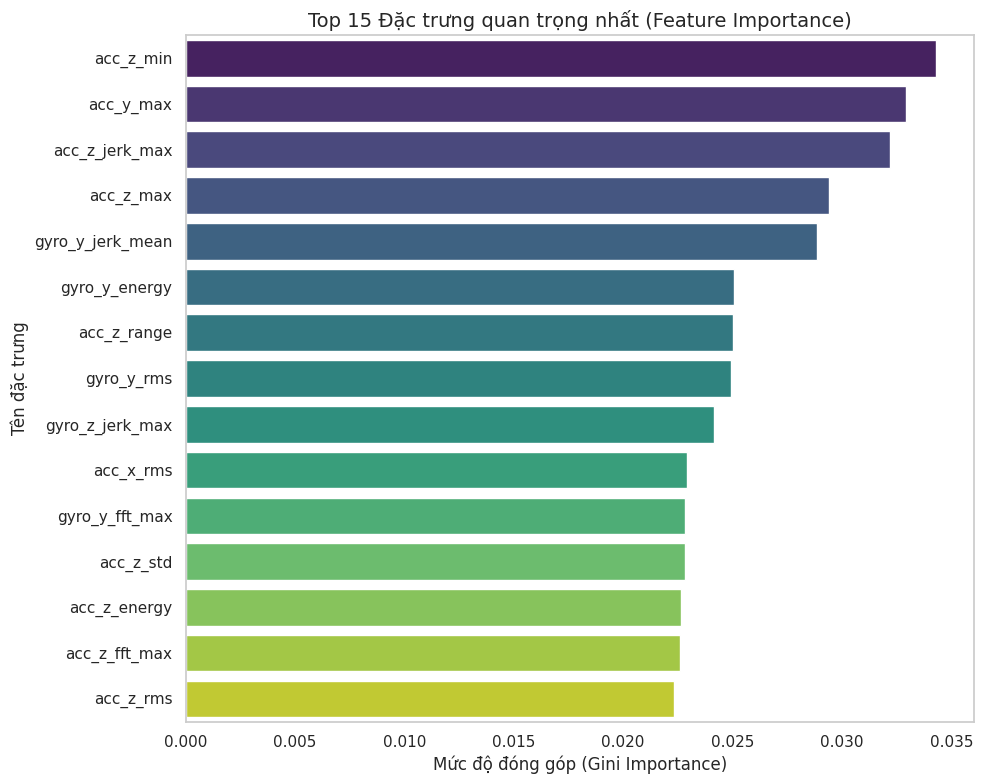

In [ ]:
# --- CODE VẼ HÌNH 3.2: FEATURE IMPORTANCE ---
# (Chạy sau khi đã train model trong Notebook 07)
def plot_feature_importance_report(model, feature_names):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:15] # Lấy Top 15

    plt.figure(figsize=(10, 8))
    sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='viridis')
    plt.title('Top 15 Đặc trưng quan trọng nhất (Feature Importance)', fontsize=14)
    plt.xlabel('Mức độ đóng góp (Gini Importance)')
    plt.ylabel('Tên đặc trưng')
    plt.grid(axis='x')
    plt.tight_layout()
    plt.show()

plot_feature_importance_report(rf_full, X_train.columns)

/tmp/ipython-input-769378815.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_30, x='Feature', y='Importance', ax=ax1, palette='viridis')
/tmp/ipython-input-769378815.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, fontsize=8)


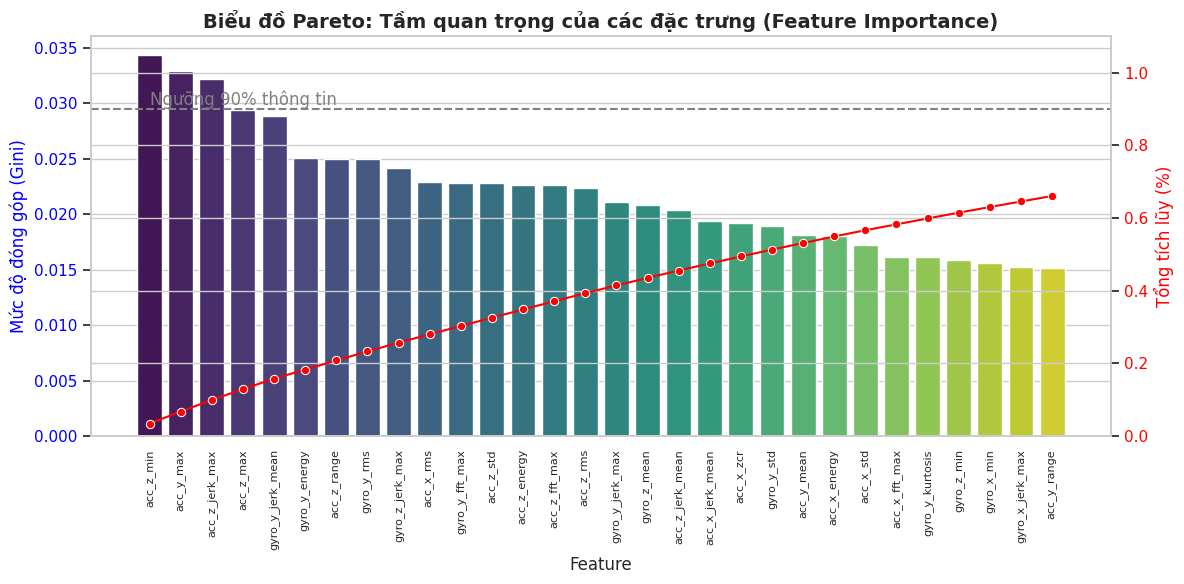

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Giả lập dữ liệu feature importance (Nếu bạn đã chạy NB 07 thì dùng biến feature_imp_df có sẵn)
# Nếu không, đây là dữ liệu mẫu để ra hình đẹp:
def plot_pareto_importance(feature_imp_df):
    # Tính tổng tích lũy
    feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
    feature_imp_df['Cumulative'] = feature_imp_df['Importance'].cumsum()

    # Chỉ lấy Top 30 để vẽ cho thoáng
    top_30 = feature_imp_df.head(30)

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Bar chart (Importance từng cái)
    sns.barplot(data=top_30, x='Feature', y='Importance', ax=ax1, palette='viridis')
    ax1.set_ylabel('Mức độ đóng góp (Gini)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, fontsize=8)

    # Line chart (Tích lũy)
    ax2 = ax1.twinx()
    sns.lineplot(data=top_30, x='Feature', y='Cumulative', ax=ax2, color='red', marker='o', sort=False)
    ax2.set_ylabel('Tổng tích lũy (%)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(0, 1.1)

    # Vẽ đường cắt 90% hoặc 95%
    ax2.axhline(0.90, color='gray', linestyle='--')
    ax2.text(0, 0.91, 'Ngưỡng 90% thông tin', color='gray')

    plt.title('Biểu đồ Pareto: Tầm quan trọng của các đặc trưng (Feature Importance)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Gọi hàm (Yêu cầu bạn đã chạy phần Feature Importance ở Notebook 07)
if 'feature_imp_df' in locals():
    plot_pareto_importance(feature_imp_df)
else:
    print("⚠️ Hãy chạy phần Feature Importance trong Notebook 07 trước!")